Train shape: (6510, 45)
Test shape : (240, 45)

Running fraction = 25% | rows = 1627

Running fraction = 50% | rows = 3255

Running fraction = 75% | rows = 4882

Running fraction = 100% | rows = 6510

Tuned GAM Data Sufficiency Results


,model,train_fraction,train_fraction_pct,n_train_rows,runtime_sec,RMSE,MAE,MAPE,sMAPE,NRMSE_%_of_mean_sales,MAE_%_of_mean_sales
0,"GAM (Tuned Raw Demand, lam=10)",0.25,25,1627,3.129,1009.447,653.611,8.504,8.088,10.054,6.510
1,"GAM (Tuned Raw Demand, lam=10)",0.50,50,3255,4.263,903.591,568.630,7.107,6.801,8.999,5.663
2,"GAM (Tuned Raw Demand, lam=10)",0.75,75,4882,5.394,905.555,500.607,4.824,4.822,9.019,4.986
3,"GAM (Tuned Raw Demand, lam=10)",1.00,100,6510,6.859,822.109,458.447,4.597,4.598,8.188,4.566



RMSE by training fraction


,model,train_fraction_pct,RMSE
0,"GAM (Tuned Raw Demand, lam=10)",25,1009.447
1,"GAM (Tuned Raw Demand, lam=10)",50,903.591
2,"GAM (Tuned Raw Demand, lam=10)",75,905.555
3,"GAM (Tuned Raw Demand, lam=10)",100,822.109



MAPE by training fraction


...


MAPE wide table


train_fraction_pct,model,25,50,75,100
0,"GAM (Tuned Raw Demand, lam=10)",8.504,7.107,4.824,4.597



sMAPE wide table


train_fraction_pct,model,25,50,75,100
0,"GAM (Tuned Raw Demand, lam=10)",8.088,6.801,4.822,4.598



Saved:
- gam_tuned_data_sufficiency_results.csv
- gam_tuned_data_sufficiency_rmse_wide.csv
- gam_tuned_data_sufficiency_mape_wide.csv
- gam_tuned_data_sufficiency_smape_wide.csv


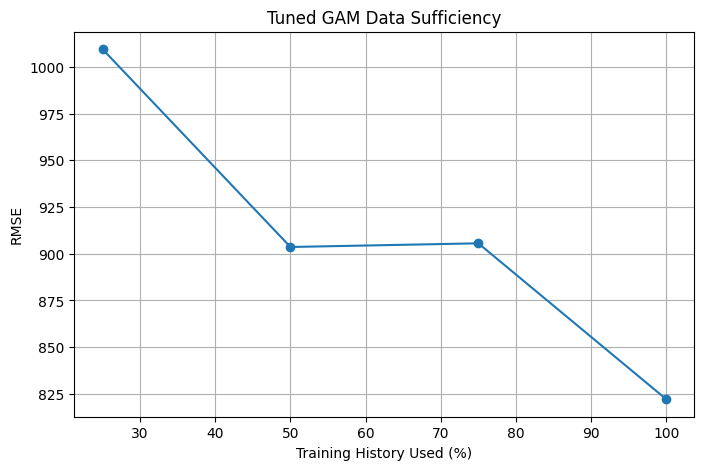

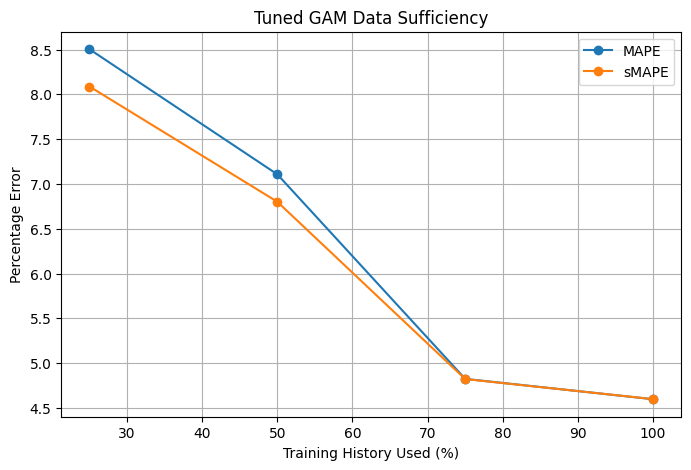

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from pygam import LinearGAM, s, l
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================================================
# 1. Load data
# =========================================================
train = pd.read_csv("training.csv", parse_dates=["week_start"])
test = pd.read_csv("test.csv", parse_dates=["week_start"])

target = "weekly_units"
drop_cols = ["weekly_units", "week_start"]
feature_cols = [c for c in train.columns if c not in drop_cols]

X_test = test[feature_cols].copy()
y_test = test[target].copy()

print("Train shape:", train.shape)
print("Test shape :", test.shape)

# =========================================================
# 2. Define tuned raw-demand GAM structure
# =========================================================
smooth_cols = [
    "lag_1",
    "lag_2",
    "lag_4",
    "lag_52",
    "rolling_mean_4",
    "rolling_std_4",
    "rolling_mean_8",
    "momentum",
    "recent_cv",
    "time_index",
    "avg_price",
    "price_rolling_4",
    "price_relative",
    "store_traffic_lag1",
    "cat_share_lag1",
]

col_index = {col: i for i, col in enumerate(feature_cols)}

terms = None
for col in feature_cols:
    idx = col_index[col]
    term = s(idx) if col in smooth_cols else l(idx)
    terms = term if terms is None else terms + term

best_lam = 10  # tuned GAM final choice

# =========================================================
# 3. Metrics
# =========================================================
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    mask = denom != 0
    if mask.sum() == 0:
        return np.nan
    return 100 * np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask])

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return 100 * np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mean_sales = np.mean(y_true)
    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
        "NRMSE_%_of_mean_sales": (100 * rmse / mean_sales) if mean_sales != 0 else np.nan,
        "MAE_%_of_mean_sales": (100 * mae / mean_sales) if mean_sales != 0 else np.nan,
    }

# =========================================================
# 4. Data sufficiency fractions
# We use the most recent fraction of training history,
# keeping the time ordering intact.
# =========================================================
fractions = [0.25, 0.50, 0.75, 1.00]
results = []

for frac in fractions:
    n_rows = int(len(train) * frac)
    train_subset = train.iloc[-n_rows:].copy()

    X_train_sub = train_subset[feature_cols].copy()
    y_train_sub = train_subset[target].copy()

    print(f"\nRunning fraction = {int(frac * 100)}% | rows = {len(train_subset)}")

    start_time = time.time()

    gam = LinearGAM(terms, lam=best_lam)
    gam.fit(X_train_sub.values, y_train_sub.values)

    elapsed = time.time() - start_time

    test_pred = gam.predict(X_test.values)
    test_pred = np.clip(test_pred, a_min=0, a_max=None)

    metrics = evaluate(y_test, test_pred)

    row = {
        "model": "GAM (Tuned Raw Demand, lam=10)",
        "train_fraction": frac,
        "train_fraction_pct": int(frac * 100),
        "n_train_rows": len(train_subset),
        "runtime_sec": elapsed,
        **metrics
    }
    results.append(row)

# =========================================================
# 5. Results table
# =========================================================
sufficiency_df = pd.DataFrame(results).sort_values("train_fraction").reset_index(drop=True)

print("\nTuned GAM Data Sufficiency Results")
display(sufficiency_df.round(3))

# =========================================================
# 6. Report-style summary tables
# =========================================================
rmse_table = sufficiency_df[["model", "train_fraction_pct", "RMSE"]].copy()
mae_table = sufficiency_df[["model", "train_fraction_pct", "MAE"]].copy()
mape_table = sufficiency_df[["model", "train_fraction_pct", "MAPE"]].copy()
smape_table = sufficiency_df[["model", "train_fraction_pct", "sMAPE"]].copy()

print("\nRMSE by training fraction")
display(rmse_table.round(3))

print("\nMAPE by training fraction")
display(mape_table.round(3))

print("\nsMAPE by training fraction")
display(smape_table.round(3))

# Wide format for report
rmse_wide = sufficiency_df.pivot_table(
    index="model", columns="train_fraction_pct", values="RMSE"
).reset_index()

mape_wide = sufficiency_df.pivot_table(
    index="model", columns="train_fraction_pct", values="MAPE"
).reset_index()

smape_wide = sufficiency_df.pivot_table(
    index="model", columns="train_fraction_pct", values="sMAPE"
).reset_index()

print("\nRMSE wide table")
display(rmse_wide.round(3))

print("\nMAPE wide table")
display(mape_wide.round(3))

print("\nsMAPE wide table")
display(smape_wide.round(3))

# =========================================================
# 7. Export
# =========================================================
sufficiency_df.to_csv("gam_tuned_data_sufficiency_results.csv", index=False)
rmse_wide.to_csv("gam_tuned_data_sufficiency_rmse_wide.csv", index=False)
mape_wide.to_csv("gam_tuned_data_sufficiency_mape_wide.csv", index=False)
smape_wide.to_csv("gam_tuned_data_sufficiency_smape_wide.csv", index=False)

print("\nSaved:")
print("- gam_tuned_data_sufficiency_results.csv")
print("- gam_tuned_data_sufficiency_rmse_wide.csv")
print("- gam_tuned_data_sufficiency_mape_wide.csv")
print("- gam_tuned_data_sufficiency_smape_wide.csv")

# =========================================================
# 8. Plot
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(sufficiency_df["train_fraction_pct"], sufficiency_df["RMSE"], marker="o", label="RMSE")
plt.xlabel("Training History Used (%)")
plt.ylabel("RMSE")
plt.title("Tuned GAM Data Sufficiency")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(sufficiency_df["train_fraction_pct"], sufficiency_df["MAPE"], marker="o", label="MAPE")
plt.plot(sufficiency_df["train_fraction_pct"], sufficiency_df["sMAPE"], marker="o", label="sMAPE")
plt.xlabel("Training History Used (%)")
plt.ylabel("Percentage Error")
plt.title("Tuned GAM Data Sufficiency")
plt.legend()
plt.grid(True)
plt.show()